# This is written by Sandeep Durga

# Import Libraries

In [81]:
# Sandeep Durga
#Loading the data from the local from file iris_challenging.csv
import pandas as pd
import seaborn as sns
import numpy as np

from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans #Kmeans - It is used to partition a dataset into K distinct, non-overlapping clusters based on feature similarity.
from sklearn import metrics #Calculating Accuracy of the model 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #confusion matrix to analyze the result
from sklearn.model_selection import cross_val_score


# ---------------------------------------------------------------------

# Load Data from CSV file 

In [82]:
# Sandeep Durga
#Reading the CSV file using the pandas in to the dataframe
df = pd.read_csv('iris_challenging.csv')

#displaying the data
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.993117,2.500989,4.542148,1.348742,versicolor
1,5.657568,3.714626,1.800290,0.531637,setosa
2,7.751423,2.662903,7.174372,2.335111,virginica
3,5.938142,3.034625,4.448674,1.426435,versicolor
4,7.054747,2.741609,4.268965,1.469104,versicolor
...,...,...,...,...,...
147,5.857968,3.949036,1.170024,0.305553,setosa
148,5.966645,2.334692,3.927622,1.186082,versicolor
149,7.197063,2.845467,5.882156,2.105997,virginica
150,10.000000,3.500000,8.000000,2.000000,virginica


## 1. Checking for data duplication

In [83]:
# Sandeep Durga
#Finding the duplicates in the given dataset
df.reset_index(drop=True, inplace=True)
duplicates = df.duplicated()
df[duplicates]

#We have no duplicate data in the rows


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species


## Analysis - We do not have the duplicated data in the given data.

# ---------------------------------------------------------------------

## 1. Check for Missing Data

## Checking for the column which has the Missing Data

In [84]:
# Sandeep Durga
#checking for the column which has the missing data
colval = df.columns[df.isnull().any()].tolist()
print(colval)

['sepal width (cm)']


## Analysis - Found the Missing Data in the "Sepal Width (cm)" Column

# ---------------------------------------------------------------------

## 1. (a) The Records with Missing Values

In [85]:
# Sandeep Durga
# Identify rows with missing values
DataMissing_rows = df[df.isnull().any(axis=1)]

# Print the rows with missing values
print(DataMissing_rows)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
18            5.635102               NaN           4.211992          1.538145   
31            5.911485               NaN           1.674489          0.613240   
64            5.513339               NaN           4.311822          1.474508   
73            5.768455               NaN           5.306520          1.537974   
76            6.185278               NaN           5.459096          2.080531   
78            4.909547               NaN           1.678274          0.388903   
118           5.676030               NaN           3.381097          1.117666   
141           6.560888               NaN           4.516092          0.931019   

        species  
18   versicolor  
31       setosa  
64   versicolor  
73    virginica  
76    virginica  
78       setosa  
118  versicolor  
141  versicolor  


## Descriptive statistics of DataFrame With Missing Values

In [86]:
# Sandeep Durga
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,152.000000,144.000000,152.000000,152.000000
mean,5.854023,3.050530,3.785097,1.232286
std,0.927025,0.469781,1.808425,0.755899
min,4.174695,2.000000,1.046191,-0.146066
25%,5.095226,2.692906,1.677963,0.479590
50%,5.810977,3.033138,4.280833,1.383734
75%,6.487654,3.371210,5.112278,1.839793
max,10.000000,4.571993,8.000000,2.556193


## Printing the rows with missing values

In [87]:
# Sandeep Durga
Data_Rows = df[df.isnull().any(axis=1)]
print(Data_Rows.isnull())
print(Data_Rows.isnull().mean())

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
18               False              True              False             False   
31               False              True              False             False   
64               False              True              False             False   
73               False              True              False             False   
76               False              True              False             False   
78               False              True              False             False   
118              False              True              False             False   
141              False              True              False             False   

     species  
18     False  
31     False  
64     False  
73     False  
76     False  
78     False  
118    False  
141    False  
sepal length (cm)    0.0
sepal width (cm)     1.0
petal length (cm)    0.0
petal width (cm)     0.0
species              0.0
dtype: flo

# Graph with Missing Values

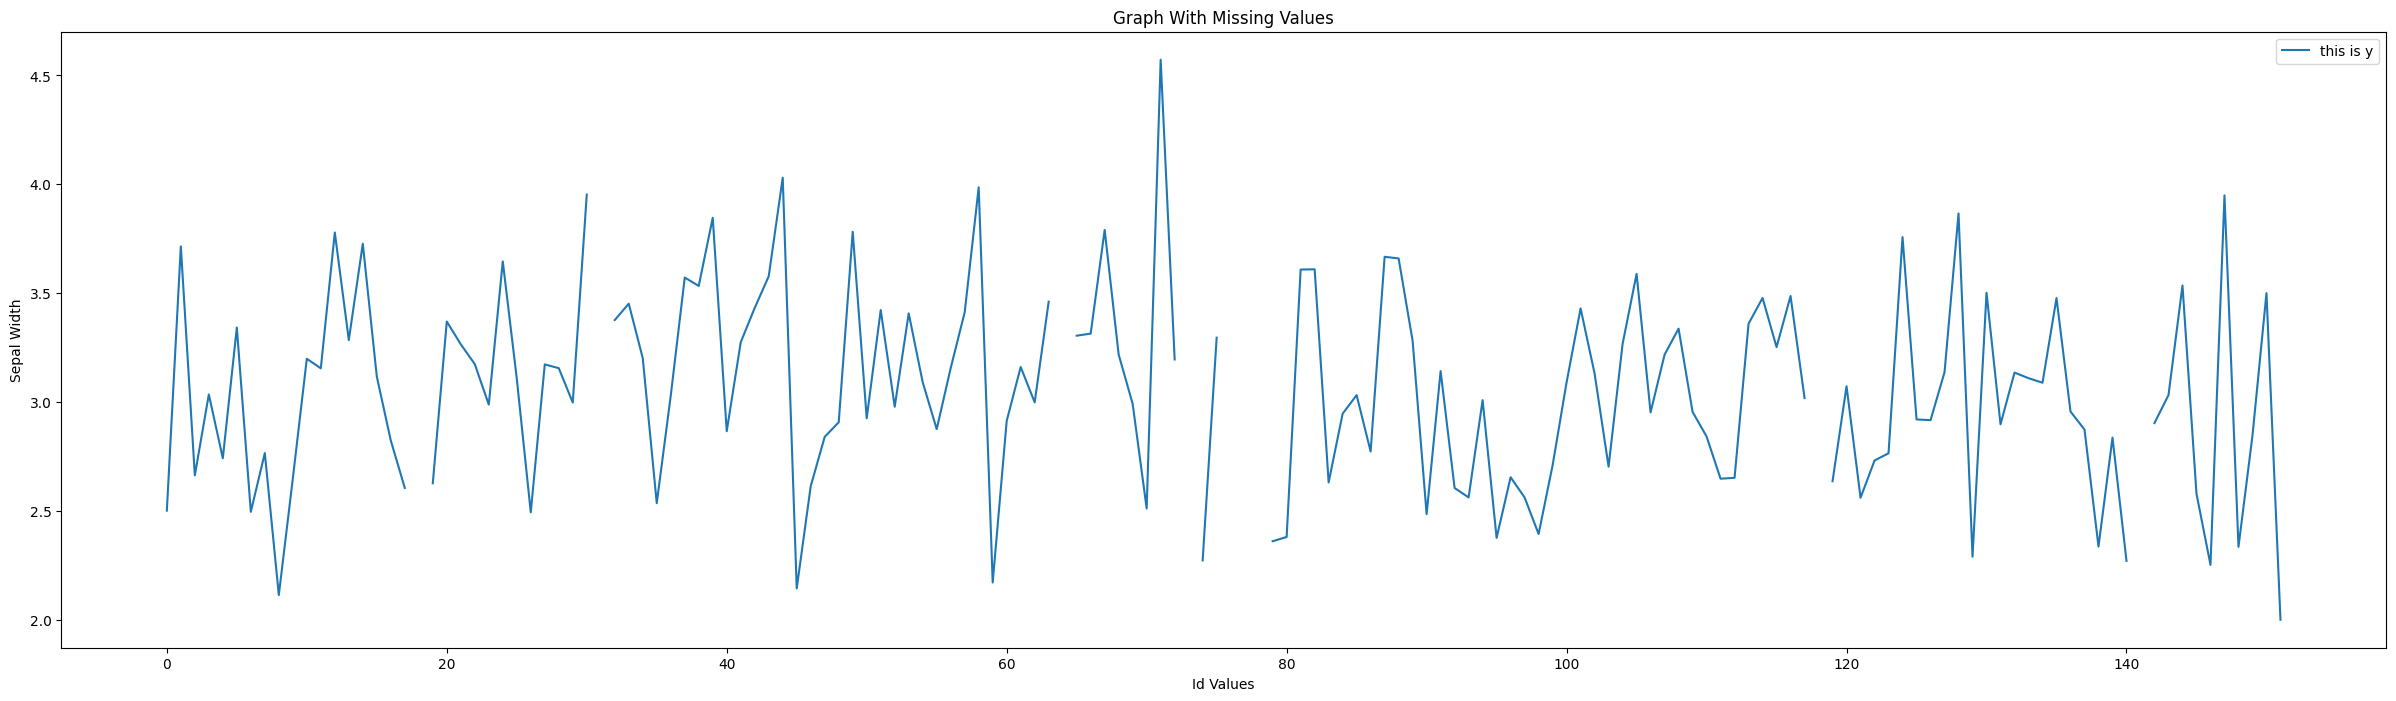

In [88]:
# Sandeep Durga
Column_to_graph = df['sepal width (cm)']
XAxisValue = np.arange(152)
plt.figure(figsize=(30, 8))
plt.plot(XAxisValue, Column_to_graph)
plt.xlabel('Id Values')
plt.ylabel('Sepal Width')
plt.title('Graph With Missing Values')
plt.legend(["this is y"])
plt.show()

# ---------------------------------------------------------------------

## 1.(a). (i) Checking By Dropping Rows

 # Graph with dropping the rows

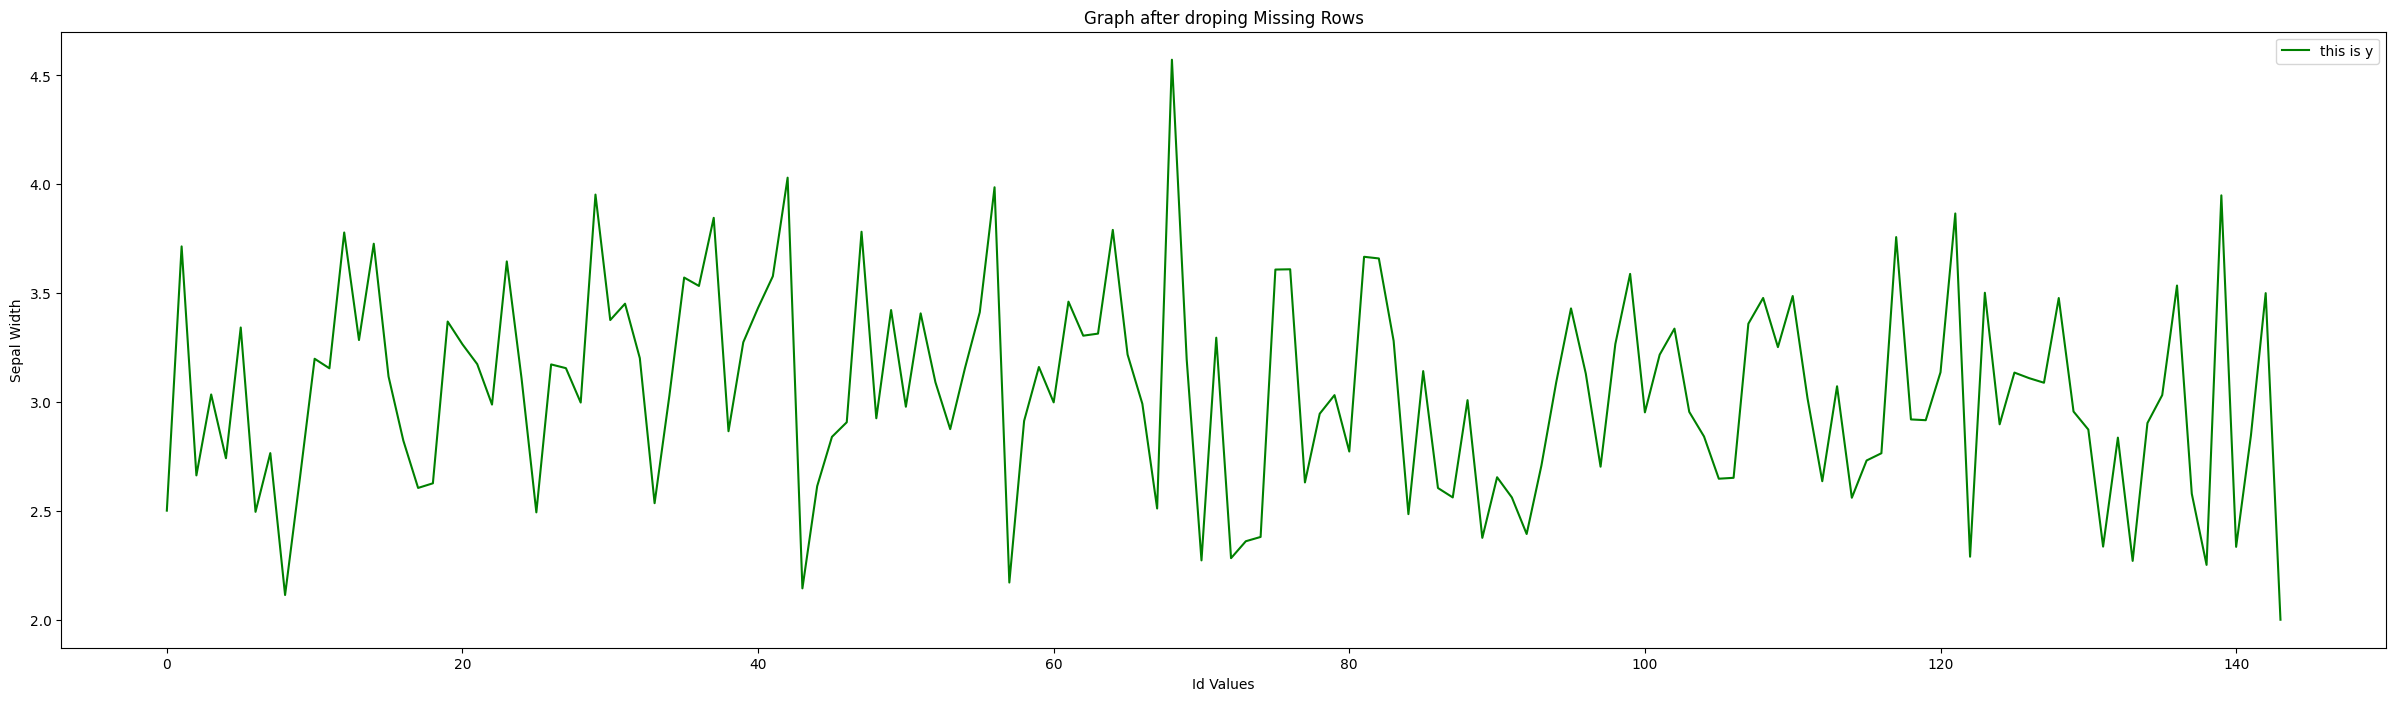

In [89]:
# Sandeep Durga
df_copy = df.copy()
df_drop = df_copy.dropna()

#print(df.loc[18,'sepal width (cm)'])
plt.figure(figsize=(30, 8))
Column_to_graph = df_drop['sepal width (cm)']
XAxisValue = np.arange(144) #(152)#(144)
plt.plot(XAxisValue, Column_to_graph, color='green')
plt.xlabel('Id Values')
plt.ylabel('Sepal Width')
plt.title('Graph after droping Missing Rows')
plt.legend(["this is y"])
plt.show()


## Descriptive statistics of DataFrame With Dropping Values

In [90]:
df_drop.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,144.000000,144.000000,144.000000,144.000000
mean,5.858691,3.050530,3.783301,1.233510
std,0.946302,0.469781,1.829560,0.766954
min,4.174695,2.000000,1.046191,-0.146066
25%,5.069533,2.692906,1.667794,0.471187
50%,5.821307,3.033138,4.280833,1.383734
75%,6.498992,3.371210,5.112278,1.871091
max,10.000000,4.571993,8.000000,2.556193


## 1.(a). (i) Imputation with Median Value

In [91]:
# Sandeep Durga
df_c = df.copy()
df_c['sepal width (cm)'] = df_c['sepal width (cm)'].fillna(df_c['sepal width (cm)'].median())

#df['sepal width (cm)'] = df['sepal width (cm)'].fillna(df['sepal width (cm)'].median())

#Checking the Rows with missing values is updated or not
print(df_c.loc[18,'sepal width (cm)'])
print(df_c.loc[31,'sepal width (cm)'])
print(df_c.loc[64,'sepal width (cm)'])
print(df_c.loc[73,'sepal width (cm)'])
print(df_c.loc[76,'sepal width (cm)'])
print(df_c.loc[78,'sepal width (cm)'])
print(df_c.loc[118,'sepal width (cm)'])
print(df_c.loc[141,'sepal width (cm)'])

3.033138148372734
3.033138148372734
3.033138148372734
3.033138148372734
3.033138148372734
3.033138148372734
3.033138148372734
3.033138148372734


## Descriptive statistics of DataFrame With Median Values

In [92]:
# Sandeep Durga
df_c.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,152.000000,152.000000,152.000000,152.000000
mean,5.854023,3.049615,3.785097,1.232286
std,0.927025,0.457184,1.808425,0.755899
min,4.174695,2.000000,1.046191,-0.146066
25%,5.095226,2.725631,1.677963,0.479590
50%,5.810977,3.033138,4.280833,1.383734
75%,6.487654,3.346516,5.112278,1.839793
max,10.000000,4.571993,8.000000,2.556193


# Graph with Imputation with median values

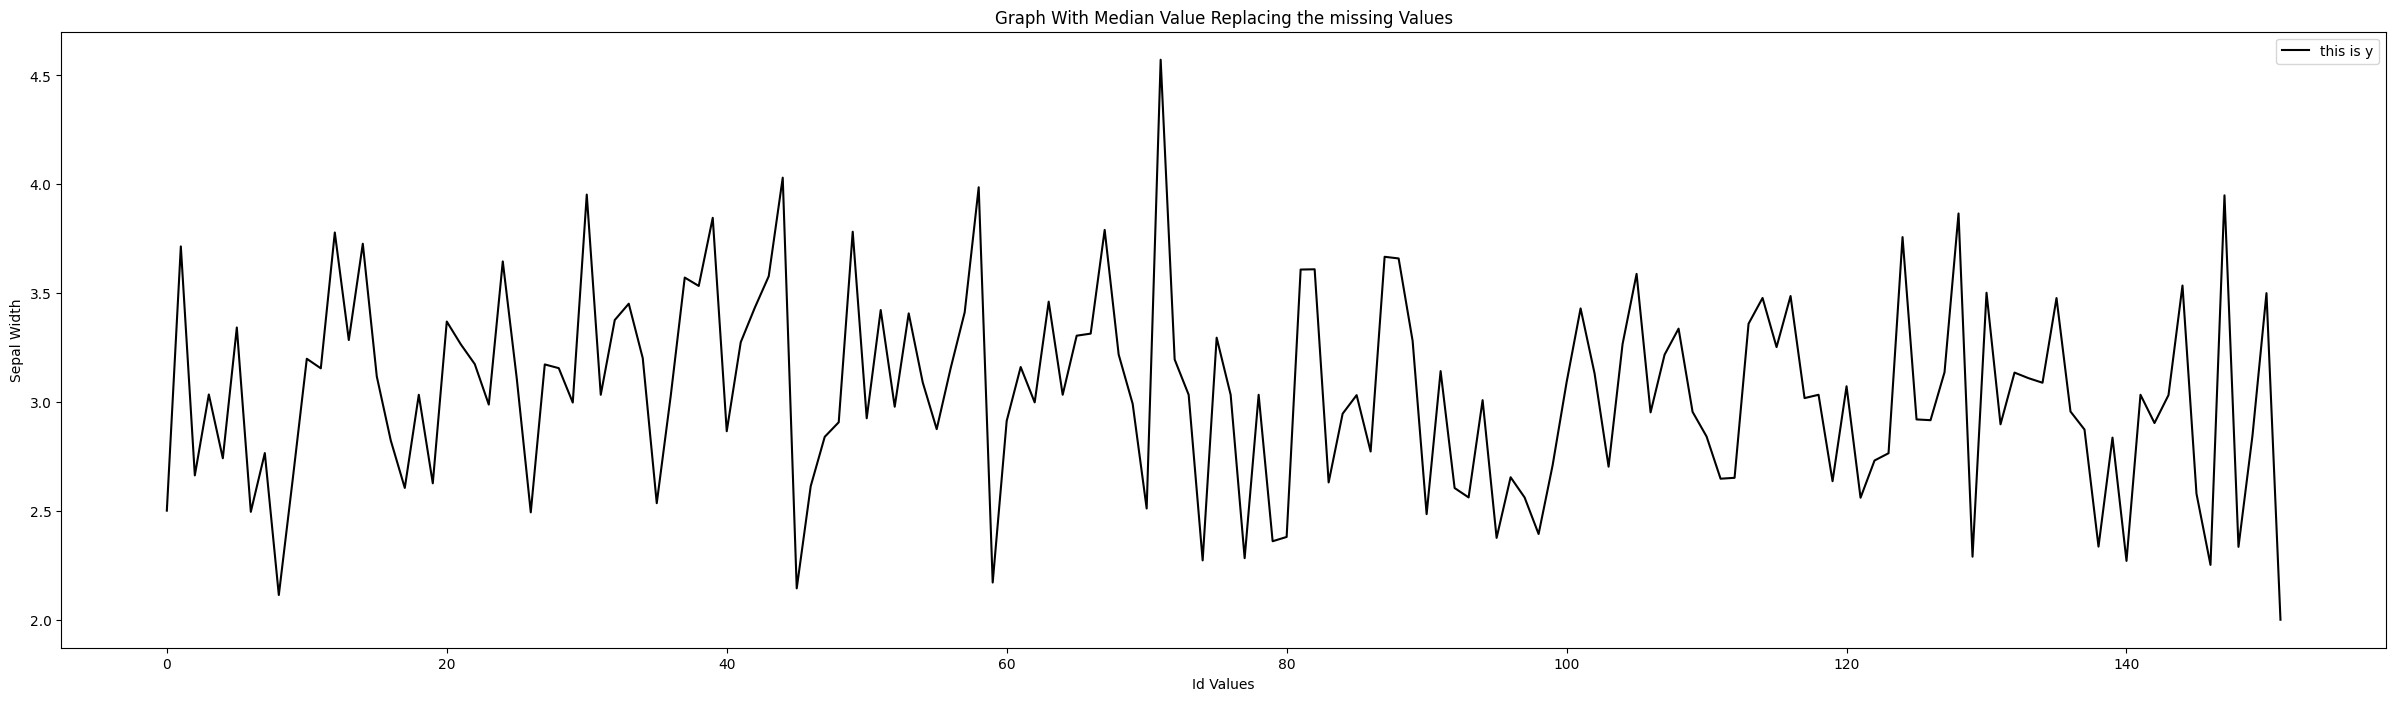

In [93]:
# Sandeep Durga
plt.figure(figsize=(30, 8))
Column_to_graph = df_c['sepal width (cm)']
XAxisValue = np.arange(152)
plt.plot(XAxisValue, Column_to_graph, color='black')
plt.xlabel('Id Values')
plt.ylabel('Sepal Width')
plt.title('Graph With Median Value Replacing the missing Values')
plt.legend(["this is y"])
plt.show()

# 1. (a). (i) Imputation with Mean Value

In [94]:
# Sandeep Durga
df_M = df.copy()
df_M['sepal width (cm)'] = df_M['sepal width (cm)'].fillna(df_M['sepal width (cm)'].mean())


#Checking the Rows with missing values is updated or not
print(df_M.loc[18,'sepal width (cm)'])
print(df_M.loc[31,'sepal width (cm)'])
print(df_M.loc[64,'sepal width (cm)'])
print(df_M.loc[73,'sepal width (cm)'])
print(df_M.loc[76,'sepal width (cm)'])
print(df_M.loc[78,'sepal width (cm)'])
print(df_M.loc[118,'sepal width (cm)'])
print(df_M.loc[141,'sepal width (cm)'])

3.0505301438798096
3.0505301438798096
3.0505301438798096
3.0505301438798096
3.0505301438798096
3.0505301438798096
3.0505301438798096
3.0505301438798096


## Descriptive statistics of DataFrame With Mean Values

In [95]:
# Sandeep Durga
df_M.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,152.000000,152.000000,152.000000,152.000000
mean,5.854023,3.050530,3.785097,1.232286
std,0.927025,0.457167,1.808425,0.755899
min,4.174695,2.000000,1.046191,-0.146066
25%,5.095226,2.725631,1.677963,0.479590
50%,5.810977,3.050530,4.280833,1.383734
75%,6.487654,3.346516,5.112278,1.839793
max,10.000000,4.571993,8.000000,2.556193


# Graph with Imputation with mean values

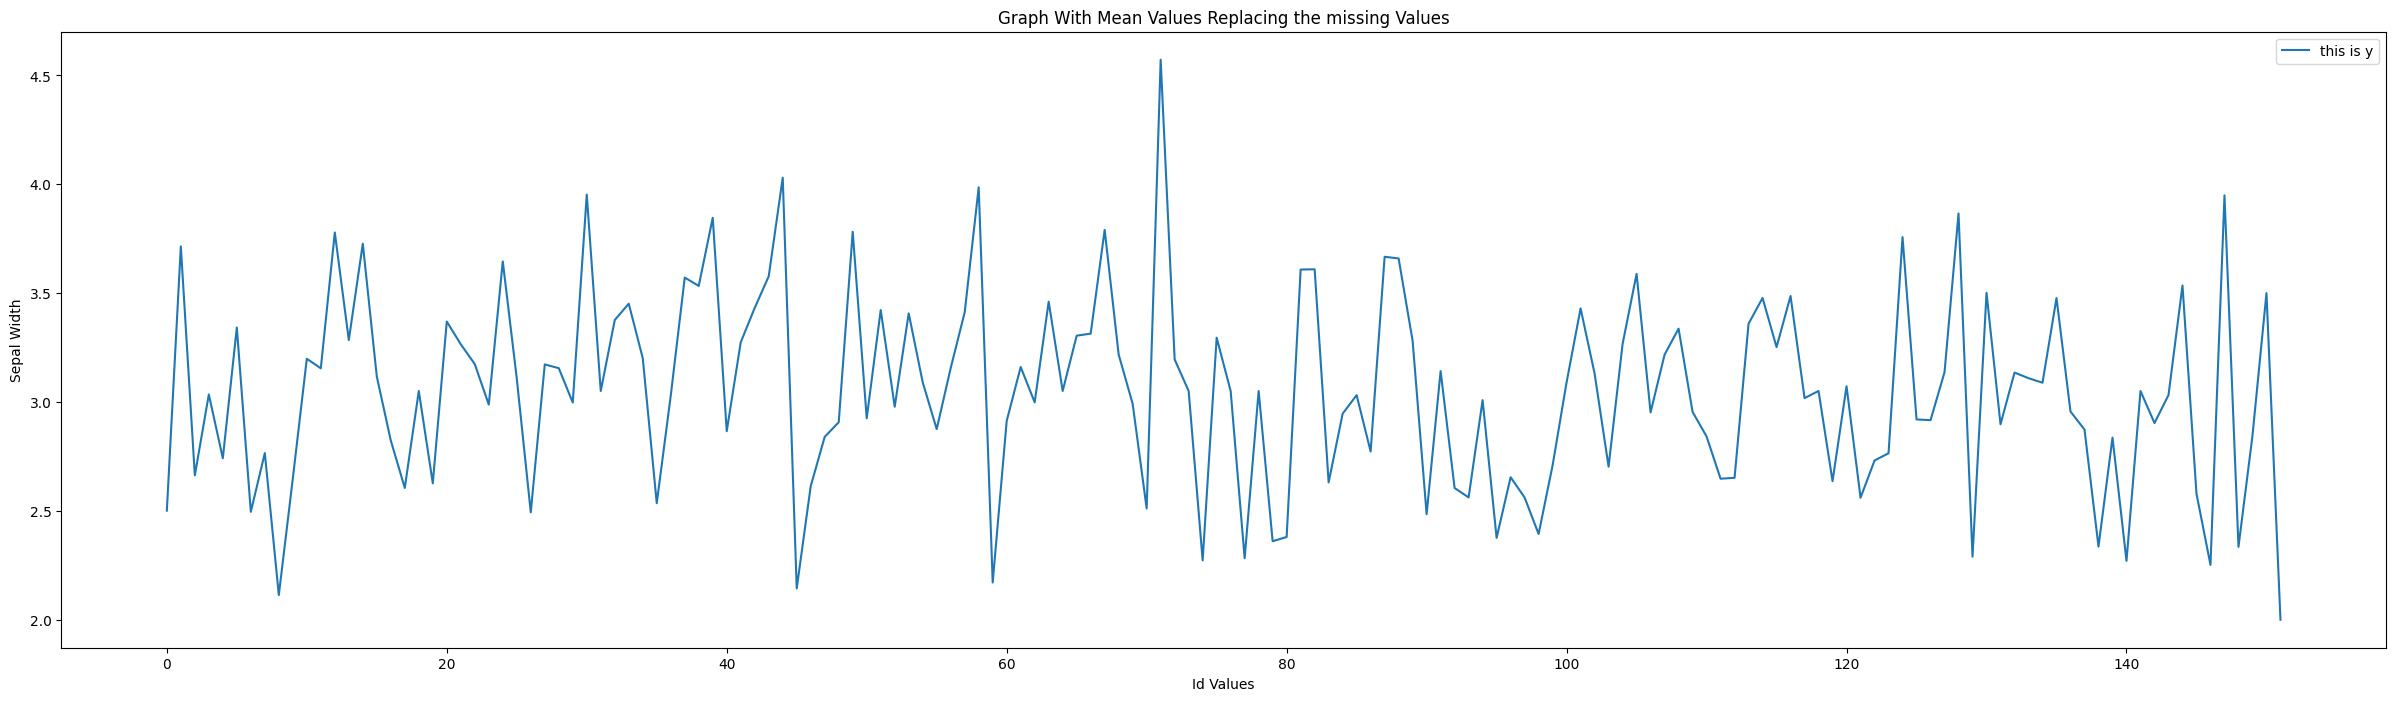

In [96]:
# Sandeep Durga
plt.figure(figsize=(30, 8))
Column_to_graph = df_M['sepal width (cm)']
XAxisValue = np.arange(152)
plt.plot(XAxisValue, Column_to_graph)
plt.xlabel('Id Values')
plt.ylabel('Sepal Width')
plt.title('Graph With Mean Values Replacing the missing Values')
plt.legend(["this is y"])
plt.show()


# Comparing Mean, Median and Dropping Rows

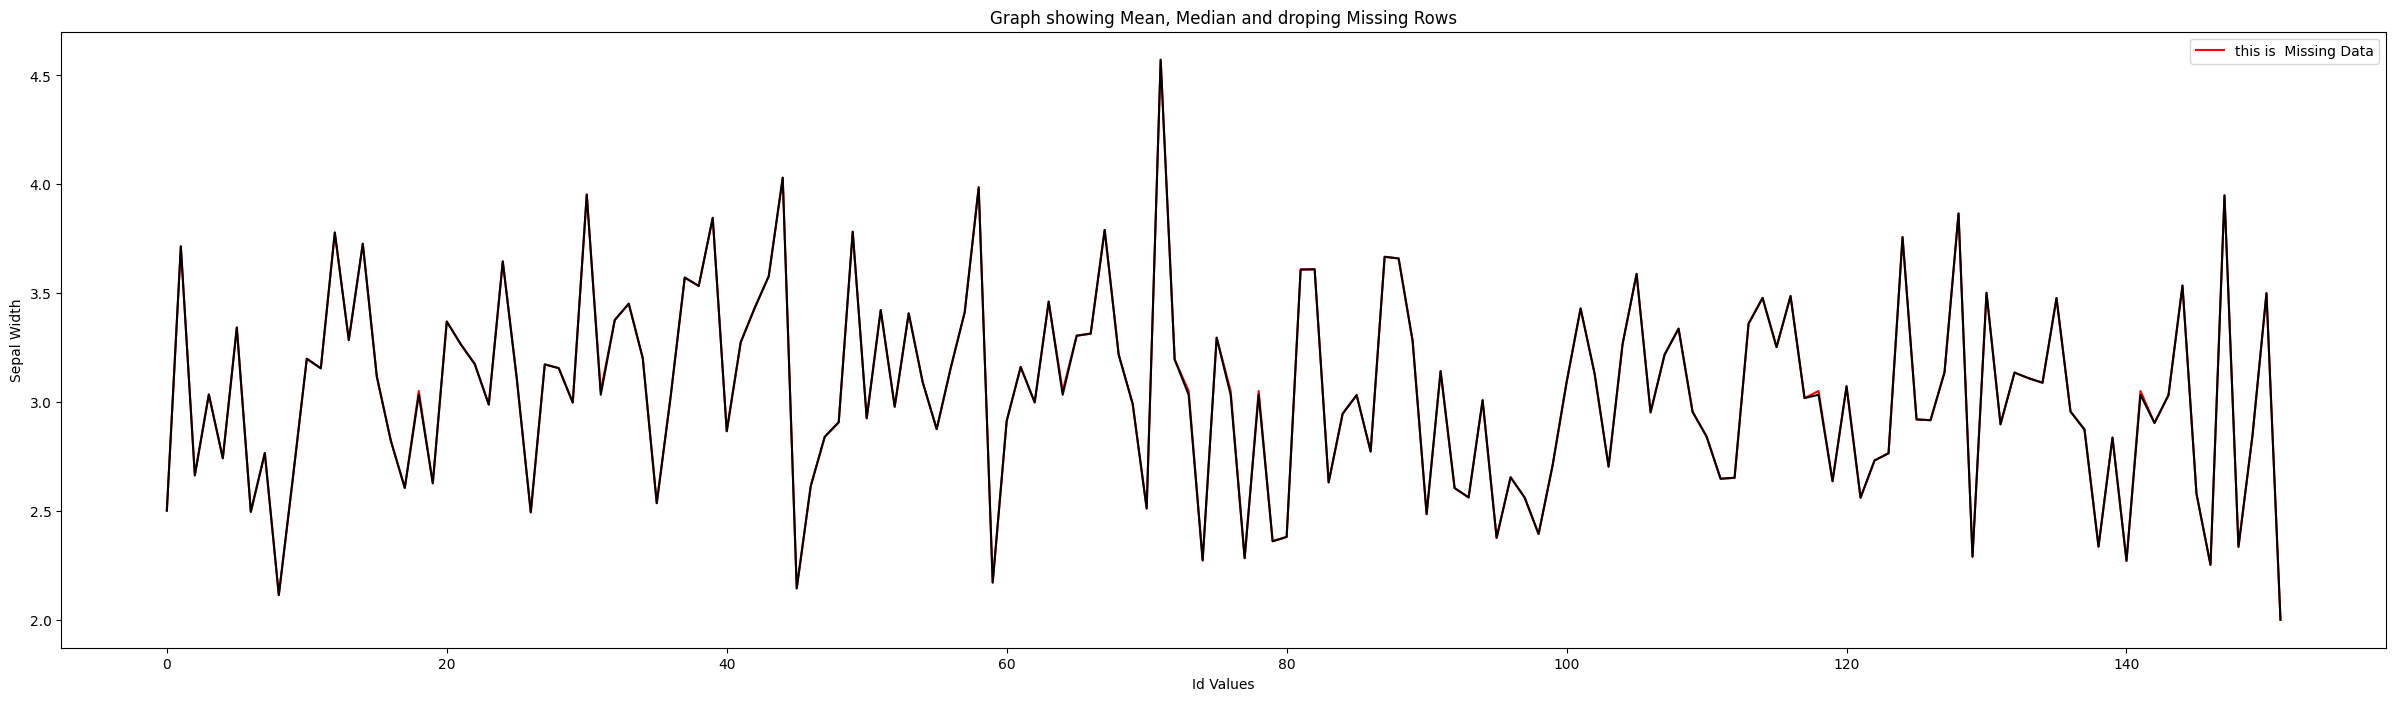

In [97]:
# Sandeep Durga
plt.figure(figsize=(30, 8))

'''
#Data from the dropping of the rows of missing data
Column_to_graph = df_drop['sepal width (cm)']
XAxisValue = np.arange(144)
plt.plot(XAxisValue, Column_to_graph, color='green')
'''

'''
#Orginal Data
Column_to_grph = df['sepal width (cm)']
XAxisVal = np.arange(152)
plt.plot(XAxisVal, Column_to_grph, color='green')
'''
#Data with the Mean values
Column_to_graph2 = df_M['sepal width (cm)']
XAxisValue2 = np.arange(152)
plt.plot(XAxisValue2, Column_to_graph2, color='red')

#Data with the Median values
Column_to_graph3 = df_c['sepal width (cm)']
XAxisValue3 = np.arange(152)
plt.plot(XAxisValue3, Column_to_graph3, color='black')

plt.xlabel('Id Values')
plt.ylabel('Sepal Width')
plt.title('Graph showing Mean, Median and droping Missing Rows')
plt.legend(["this is  Missing Data"])
plt.show()


## Analysis - about which is used from the Mean, Median and Deleting duplicate rows.

## When examining the descriptive statistics, the mean can be considered appropriate as it is closely represents the distribution of the data, even after removing rows with missing values.


# Checking for duplicate data

In [98]:
# Sandeep Durga
#Finding the duplicates in the given dataset
duplicates = df.duplicated()
df[duplicates]

#There is no duplicate data present in this dataframe


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species


## Cannot find any duplicate rows in the data given in the first question

# ---------------------------------------------------------------------

# 2. Draw Box Plot to spot outliers.

# ---------------------------------------------------------------------

## BOX PLOT for Sepal Length (cm)

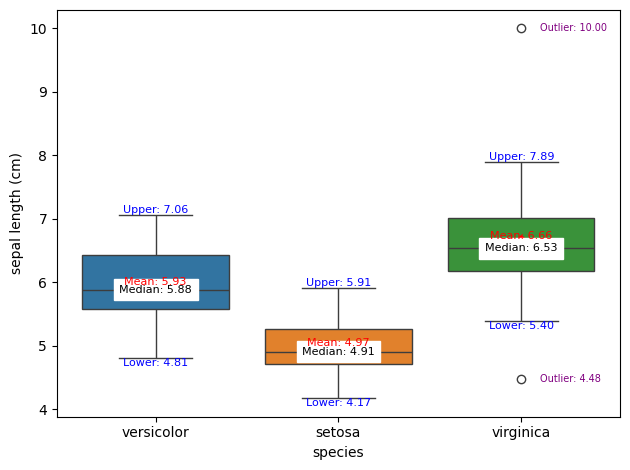

      species  Outliers (%)  Non-Outliers (%)  Outlier Count  Total Count
0      setosa      0.000000        100.000000              0           51
1  versicolor      0.000000        100.000000              0           50
2   virginica      3.921569         96.078431              2           51


In [99]:
# Sandeep Durga
ax = sns.boxplot(data=df, x="species", y="sepal length (cm)", hue="species")
species_list = df["species"].unique()


for i, species in enumerate(species_list):
    # Filter the data for each species
    vals = df[df["species"] == species]["sepal length (cm)"]
    
    # Calculate statistics
    median_val = vals.median()
    mean_val = vals.mean()
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1
    whisker_low = vals[vals >= q1 - 1.5 * iqr].min()
    whisker_high = vals[vals <= q3 + 1.5 * iqr].max()
    outliers = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    
    # Check if we have enough box artists
    if i < len(ax.artists):
        # Get the box for this species
        box = ax.artists[i]
        x = box.get_x() + box.get_width() / 2
        
        # Annotate median
        ax.text(x, median_val, f'Median: {median_val:.2f}', ha='center', va='center', 
                fontsize=8, color='black', backgroundcolor='white')
        
        # Annotate mean
        ax.text(x, mean_val, f'Mean: {mean_val:.2f}', ha='center', va='bottom', 
                fontsize=8, color='red')
        ax.plot(x, mean_val, 'D', color='red')  # Plot red diamond for mean
        
        # Annotate whiskers
        ax.text(x, whisker_low, f'Lower: {whisker_low:.2f}', ha='center', va='top', 
                fontsize=8, color='blue')
        ax.text(x, whisker_high, f'Upper: {whisker_high:.2f}', ha='center', va='bottom', 
                fontsize=8, color='blue')
        
        # Annotate outliers if any
        if len(outliers) > 0:
            for outlier in outliers:
                ax.text(x + 0.1, outlier, f'Outlier: {outlier:.2f}', ha='left', va='center', 
                        fontsize=7, color='purple')
    else:
        # Alternative: use the index directly if box artists don't match species count
        ax.text(i, median_val, f'Median: {median_val:.2f}', ha='center', va='center', 
                fontsize=8, color='black', backgroundcolor='white')
        ax.text(i, mean_val, f'Mean: {mean_val:.2f}', ha='center', va='bottom', 
                fontsize=8, color='red')
        ax.plot(i, mean_val, 'D', color='red')
        
        ax.text(i, whisker_low, f'Lower: {whisker_low:.2f}', ha='center', va='top', 
                fontsize=8, color='blue')
        ax.text(i, whisker_high, f'Upper: {whisker_high:.2f}', ha='center', va='bottom', 
                fontsize=8, color='blue')
        
        if len(outliers) > 0:
            for outlier in outliers:
                ax.text(i + 0.1, outlier, f'Outlier: {outlier:.2f}', ha='left', va='center', 
                        fontsize=7, color='purple')

plt.tight_layout()
plt.show()


#The Outliers and the percentage of outliers and non-outliers
group_column = 'species'

group_outlier_stats = []

for group, group_df in df.groupby(group_column):
    Q1 = group_df['sepal length (cm)'].quantile(0.25)
    Q3 = group_df['sepal length (cm)'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = group_df[(group_df['sepal length (cm)'] < lower_bound) | 
                        (group_df['sepal length (cm)'] > upper_bound)]
    
    percent_outliers = len(outliers) / len(group_df) * 100
    percent_non_outliers = 100 - percent_outliers

    group_outlier_stats.append({
        group_column: group,
        'Outliers (%)': percent_outliers,
        'Non-Outliers (%)': percent_non_outliers,
        'Outlier Count': len(outliers),
        'Total Count': len(group_df)
    })

# Create a summary DataFrame
summary_df = pd.DataFrame(group_outlier_stats)
print(summary_df)

## Analysis - Boxplot shows distribution of Sepal Length (cm) by Species. For Virginica Species the outliers are for 2 out of 51 count which means this occur rarely in this particular species.

# ---------------------------------------------------------------------

# BOX PLOT for Sepal Width (cm)

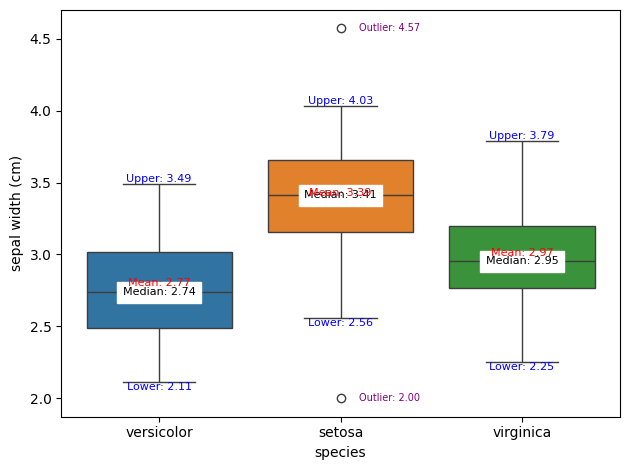

      species  Outliers (%)  Non-Outliers (%)  Outlier Count  Total Count
0      setosa      3.921569         96.078431              2           51
1  versicolor      0.000000        100.000000              0           50
2   virginica      0.000000        100.000000              0           51


In [100]:
# Sandeep Durga
ax = sns.boxplot(data = df, x = "species", y = "sepal width (cm)", hue="species")
species_list = df["species"].unique()

for i, species in enumerate(species_list):
    # Filter the data for each species
    vals = df[df["species"] == species]["sepal width (cm)"]
    
    # Calculate statistics
    median_val = vals.median()
    mean_val = vals.mean()
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1
    whisker_low = vals[vals >= q1 - 1.5 * iqr].min()
    whisker_high = vals[vals <= q3 + 1.5 * iqr].max()
    outliers = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    
    # Check if we have enough box artists
    if i < len(ax.artists):
        # Get the box for this species
        box = ax.artists[i]
        x = box.get_x() + box.get_width() / 2

        offset = 0.008 * (vals.max() - vals.min())
        
        # Annotate median
        ax.text(x, median_val + offset, f'Median: {median_val:.2f}', ha='center', va='center', 
                fontsize=8, color='black', backgroundcolor='white')
        
        # Annotate mean
        ax.text(x, mean_val - offset, f'Mean: {mean_val:.2f}', ha='center', va='bottom', 
                fontsize=8, color='red')
        ax.plot(x, mean_val, 'D', color='red')  # Plot red diamond for mean
        
        # Annotate whiskers
        ax.text(x, whisker_low, f'Lower: {whisker_low:.2f}', ha='center', va='top', 
                fontsize=8, color='blue')
        ax.text(x, whisker_high, f'Upper: {whisker_high:.2f}', ha='center', va='bottom', 
                fontsize=8, color='blue')
        
        # Annotate outliers if any
        if len(outliers) > 0:
            for outlier in outliers:
                ax.text(x + 0.1, outlier, f'Outlier: {outlier:.2f}', ha='left', va='center', 
                        fontsize=7, color='purple')
    else:
        # Alternative: use the index directly if box artists don't match species count
        ax.text(i, median_val, f'Median: {median_val:.2f}', ha='center', va='center', 
                fontsize=8, color='black', backgroundcolor='white')
        ax.text(i, mean_val, f'Mean: {mean_val:.2f}', ha='center', va='bottom', 
                fontsize=8, color='red')
        ax.plot(i, mean_val, 'D', color='red')
        
        ax.text(i, whisker_low, f'Lower: {whisker_low:.2f}', ha='center', va='top', 
                fontsize=8, color='blue')
        ax.text(i, whisker_high, f'Upper: {whisker_high:.2f}', ha='center', va='bottom', 
                fontsize=8, color='blue')
        
        if len(outliers) > 0:
            for outlier in outliers:
                ax.text(i + 0.1, outlier, f'Outlier: {outlier:.2f}', ha='left', va='center', 
                        fontsize=7, color='purple')

plt.tight_layout()
plt.show()

#The Outliers and the percentage of outliers and non-outliers
group_column = 'species'

group_outlier_stats = []

for group, group_df in df.groupby(group_column):
    Q1 = group_df['sepal width (cm)'].quantile(0.25)
    Q3 = group_df['sepal width (cm)'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = group_df[(group_df['sepal width (cm)'] < lower_bound) | 
                        (group_df['sepal width (cm)'] > upper_bound)]
    
    percent_outliers = len(outliers) / len(group_df) * 100
    percent_non_outliers = 100 - percent_outliers

    group_outlier_stats.append({
        group_column: group,
        'Outliers (%)': percent_outliers,
        'Non-Outliers (%)': percent_non_outliers,
        'Outlier Count': len(outliers),
        'Total Count': len(group_df)
    })

# Create a summary DataFrame
summary_df = pd.DataFrame(group_outlier_stats)
print(summary_df)

## Analysis - Boxplot shows distribution of Sepal Width (cm) by Species. For Setosa Species the outliers are for 2 out of 51 count which means this occur rarely in this particular species.

# ---------------------------------------------------------------------

# BOX PLOT for Petal Length (cm)

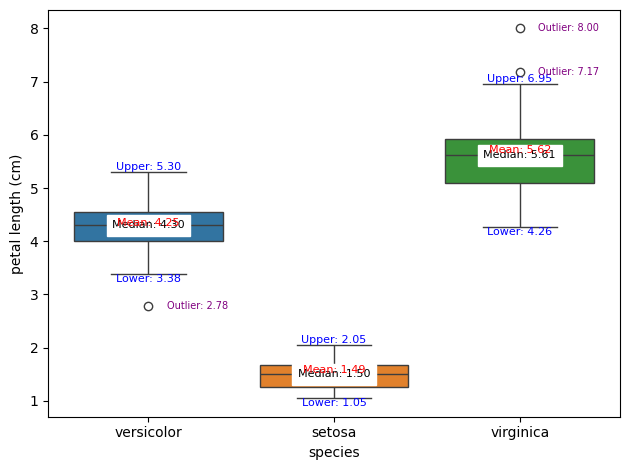

      species  Outliers (%)  Non-Outliers (%)  Outlier Count  Total Count
0      setosa      0.000000        100.000000              0           51
1  versicolor      2.000000         98.000000              1           50
2   virginica      3.921569         96.078431              2           51


In [101]:

# Sandeep Durga
ax = sns.boxplot(data = df, x = "species", y = "petal length (cm)", hue="species")
species_list = df["species"].unique()

for i, species in enumerate(species_list):
    # Filter the data for each species
    vals = df[df["species"] == species]["petal length (cm)"]
    
    # Calculate statistics
    median_val = vals.median()
    mean_val = vals.mean()
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1
    whisker_low = vals[vals >= q1 - 1.5 * iqr].min()
    whisker_high = vals[vals <= q3 + 1.5 * iqr].max()
    outliers = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    
    # Check if we have enough box artists
    if i < len(ax.artists):
        # Get the box for this species
        box = ax.artists[i]
        x = box.get_x() + box.get_width() / 2

        offset = 0.008 * (vals.max() - vals.min())
        
        # Annotate median
        ax.text(x, median_val + offset, f'Median: {median_val:.2f}', ha='center', va='center', 
                fontsize=8, color='black', backgroundcolor='white')
        
        # Annotate mean
        ax.text(x, mean_val - offset, f'Mean: {mean_val:.2f}', ha='center', va='bottom', 
                fontsize=8, color='red')
        ax.plot(x, mean_val, 'D', color='red')  # Plot red diamond for mean
        
        # Annotate whiskers
        ax.text(x, whisker_low, f'Lower: {whisker_low:.2f}', ha='center', va='top', 
                fontsize=8, color='blue')
        ax.text(x, whisker_high, f'Upper: {whisker_high:.2f}', ha='center', va='bottom', 
                fontsize=8, color='blue')
        
        # Annotate outliers if any
        if len(outliers) > 0:
            for outlier in outliers:
                ax.text(x + 0.1, outlier, f'Outlier: {outlier:.2f}', ha='left', va='center', 
                        fontsize=7, color='purple')
    else:
        # Alternative: use the index directly if box artists don't match species count
        ax.text(i, median_val, f'Median: {median_val:.2f}', ha='center', va='center', 
                fontsize=8, color='black', backgroundcolor='white')
        ax.text(i, mean_val, f'Mean: {mean_val:.2f}', ha='center', va='bottom', 
                fontsize=8, color='red')
        ax.plot(i, mean_val, 'D', color='red')
        
        ax.text(i, whisker_low, f'Lower: {whisker_low:.2f}', ha='center', va='top', 
                fontsize=8, color='blue')
        ax.text(i, whisker_high, f'Upper: {whisker_high:.2f}', ha='center', va='bottom', 
                fontsize=8, color='blue')
        
        if len(outliers) > 0:
            for outlier in outliers:
                ax.text(i + 0.1, outlier, f'Outlier: {outlier:.2f}', ha='left', va='center', 
                        fontsize=7, color='purple')

plt.tight_layout()
plt.show()



#The Outliers and the percentage of outliers and non-outliers
group_column = 'species'

group_outlier_stats = []

for group, group_df in df.groupby(group_column):
    Q1 = group_df['petal length (cm)'].quantile(0.25)
    Q3 = group_df['petal length (cm)'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = group_df[(group_df['petal length (cm)'] < lower_bound) | 
                        (group_df['petal length (cm)'] > upper_bound)]
    
    percent_outliers = len(outliers) / len(group_df) * 100
    percent_non_outliers = 100 - percent_outliers

    group_outlier_stats.append({
        group_column: group,
        'Outliers (%)': percent_outliers,
        'Non-Outliers (%)': percent_non_outliers,
        'Outlier Count': len(outliers),
        'Total Count': len(group_df)
    })

# Create a summary DataFrame
summary_df = pd.DataFrame(group_outlier_stats)
print(summary_df)

## Analysis - Boxplot shows distribution of Petal Length (cm) by Species. 
## - For the Versicolor the outlisers are in one case that is the minimum outlier.
## - For the Virginica the outliers are in two cases which is similar to the data in the above in the Sepal Length (cm) which we can see in this case too. So, this is the is rare in this particular species.

# ---------------------------------------------------------------------

# BOX PLOT for Petal Width (cm)

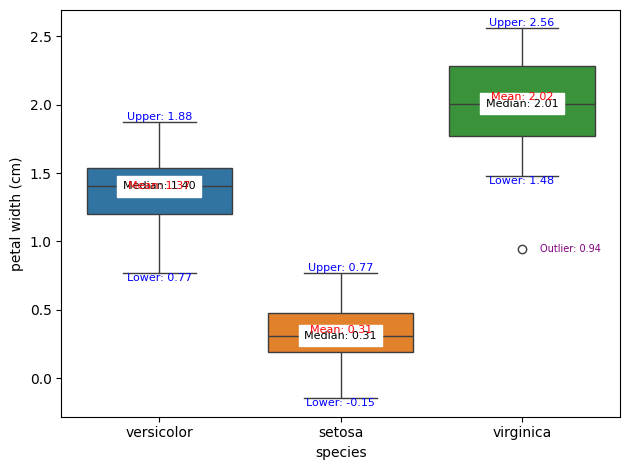

      species  Outliers (%)  Non-Outliers (%)  Outlier Count  Total Count
0      setosa      0.000000        100.000000              0           51
1  versicolor      0.000000        100.000000              0           50
2   virginica      1.960784         98.039216              1           51


In [102]:
# Sandeep Durga
#sns.boxplot(data = df, x = "species", y = "petal width (cm)", hue="species")

ax = sns.boxplot(data = df, x = "species", y = "petal width (cm)", hue="species")
species_list = df["species"].unique()

for i, species in enumerate(species_list):
    # Filter the data for each species
    vals = df[df["species"] == species]["petal width (cm)"]
    
    # Calculate statistics
    median_val = vals.median()
    mean_val = vals.mean()
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1
    whisker_low = vals[vals >= q1 - 1.5 * iqr].min()
    whisker_high = vals[vals <= q3 + 1.5 * iqr].max()
    outliers = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    
    # Check if we have enough box artists
    if i < len(ax.artists):
        # Get the box for this species
        box = ax.artists[i]
        x = box.get_x() + box.get_width() / 2

        offset = 0.008 * (vals.max() - vals.min())
        
        # Annotate median
        ax.text(x, median_val + offset, f'Median: {median_val:.2f}', ha='center', va='center', 
                fontsize=8, color='black', backgroundcolor='white')
        
        # Annotate mean
        ax.text(x, mean_val - offset, f'Mean: {mean_val:.2f}', ha='center', va='bottom', 
                fontsize=8, color='red')
        ax.plot(x, mean_val, 'D', color='red')  # Plot red diamond for mean
        
        # Annotate whiskers
        ax.text(x, whisker_low, f'Lower: {whisker_low:.2f}', ha='center', va='top', 
                fontsize=8, color='blue')
        ax.text(x, whisker_high, f'Upper: {whisker_high:.2f}', ha='center', va='bottom', 
                fontsize=8, color='blue')
        
        # Annotate outliers if any
        if len(outliers) > 0:
            for outlier in outliers:
                ax.text(x + 0.1, outlier, f'Outlier: {outlier:.2f}', ha='left', va='center', 
                        fontsize=7, color='purple')
    else:
        # Alternative: use the index directly if box artists don't match species count
        ax.text(i, median_val, f'Median: {median_val:.2f}', ha='center', va='center', 
                fontsize=8, color='black', backgroundcolor='white')
        ax.text(i, mean_val, f'Mean: {mean_val:.2f}', ha='center', va='bottom', 
                fontsize=8, color='red')
        ax.plot(i, mean_val, 'D', color='red')
        
        ax.text(i, whisker_low, f'Lower: {whisker_low:.2f}', ha='center', va='top', 
                fontsize=8, color='blue')
        ax.text(i, whisker_high, f'Upper: {whisker_high:.2f}', ha='center', va='bottom', 
                fontsize=8, color='blue')
        
        if len(outliers) > 0:
            for outlier in outliers:
                ax.text(i + 0.1, outlier, f'Outlier: {outlier:.2f}', ha='left', va='center', 
                        fontsize=7, color='purple')

plt.tight_layout()
plt.show()


#The Outliers and the percentage of outliers and non-outliers
group_column = 'species'

group_outlier_stats = []

for group, group_df in df.groupby(group_column):
    Q1 = group_df['petal width (cm)'].quantile(0.25)
    Q3 = group_df['petal width (cm)'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = group_df[(group_df['petal width (cm)'] < lower_bound) | 
                        (group_df['petal width (cm)'] > upper_bound)]
    
    percent_outliers = len(outliers) / len(group_df) * 100
    percent_non_outliers = 100 - percent_outliers

    group_outlier_stats.append({
        group_column: group,
        'Outliers (%)': percent_outliers,
        'Non-Outliers (%)': percent_non_outliers,
        'Outlier Count': len(outliers),
        'Total Count': len(group_df)
    })

# Create a summary DataFrame
summary_df = pd.DataFrame(group_outlier_stats)
print(summary_df)

## 2. (b) Analysis - Boxplot shows distribution of Petal Width (cm) by Species. 
## - For the Virginica Species the outliers are for 1 out of 51 count which means this occur rarely in this particular species. Which also occurs in the petal Length (cm) which we had seen in the above case.

# ---------------------------------------------------------------------

# 3. The Scatterplot Matrix

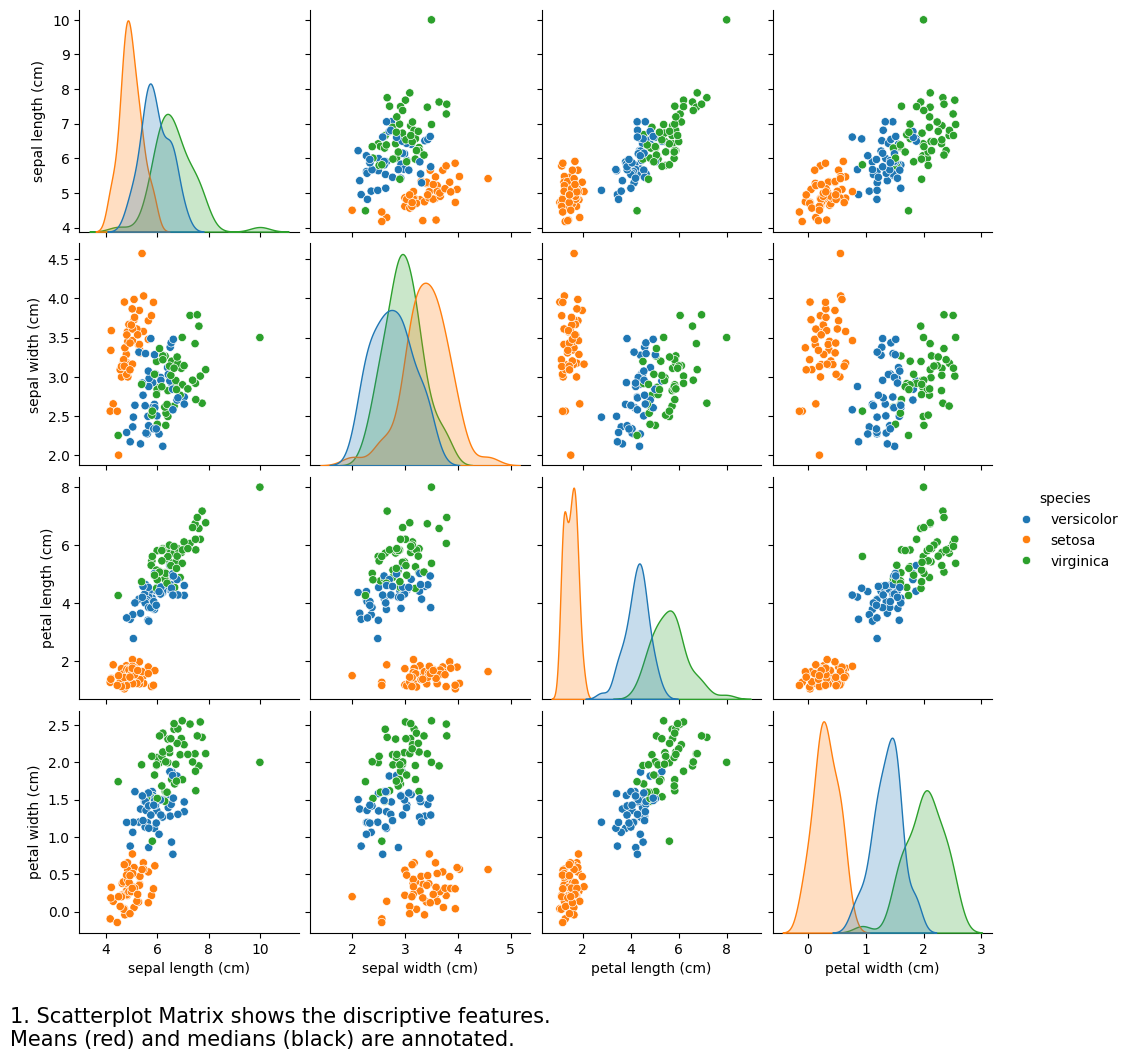

In [103]:
# Sandeep Durga
sns.pairplot(df, hue="species")

plt.figtext(0.0, -0.05, 
            "1. Scatterplot Matrix shows the discriptive features.\n"
            "Means (red) and medians (black) are annotated.",
            wrap=True, horizontalalignment='left', fontsize=15)

plt.show()

## 3. (a). Explain which two features show the clearest separation between species.
## - The Petal lenght (cm) and the Petal Width (cm) these two features show clear separation visulally when we observe. As though their is a bit overlap but compared to other features the overlap is not that much.

## 3. (b). Explain the plot
## - The Setosa clusters are always seen separate from the other clusters in the features.
## - The Versicolor and Virginica clusters can be seen close and overlapping in many cases.
## - The Sepal lenght and the petal width, Petal length and Petal width,Sepal length and Petal Width clusters are distributed in the Positive Correlation.
## - The Petal Width and Sepal Width clusters are distributed which suggests no correlation.


# 4. The HeatMap 

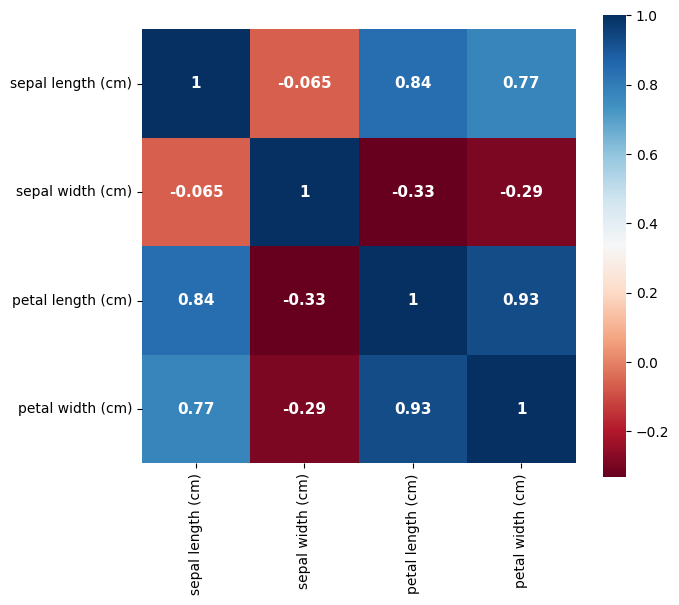

In [104]:
# Sandeep Durga
df2_cpy = df.copy();
df2_cpy = df2_cpy.drop(columns = ["species"])
corr1 = df2_cpy.corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr1, annot = True, square = True, cmap='RdBu', annot_kws={'fontsize':11, 'fontweight':'bold'})
plt.show()


## Positively and Negatively Correlated features 
## - Positively correlated features are Petal Lenght and Petal Width.(0.98)
## - Negatively correlated features are Petal Width and Sepal Width.(-0.29)

## Analyzing
## - Sepal Length has positive correlation with Petal Length.
## - Petal Width has negative correlation with the Sepal Width.
## - Petal Width and Petal Length has the strong correlation.

# ---------------------------------------------------------------------

## SPLIT THE DATA

In [105]:
# Sandeep Durga
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.993117,2.500989,4.542148,1.348742,versicolor
1,5.657568,3.714626,1.800290,0.531637,setosa
2,7.751423,2.662903,7.174372,2.335111,virginica
3,5.938142,3.034625,4.448674,1.426435,versicolor
4,7.054747,2.741609,4.268965,1.469104,versicolor
...,...,...,...,...,...
147,5.857968,3.949036,1.170024,0.305553,setosa
148,5.966645,2.334692,3.927622,1.186082,versicolor
149,7.197063,2.845467,5.882156,2.105997,virginica
150,10.000000,3.500000,8.000000,2.000000,virginica


In [106]:
# Sandeep Durga
df['sepal width (cm)'] = df['sepal width (cm)'].fillna(df['sepal width (cm)'].mean())

In [107]:
# Sandeep Durga
print(df.loc[76,'sepal width (cm)']) #Testing whether the mean data is updated or not in the data

3.0505301438798096


In [108]:
# Sandeep Durga
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Normalization = (current value - min value) / (max value - min value)
# Standardization = (current value - average of column) / std dev of column
from sklearn.preprocessing import StandardScaler
# For cross validation
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

import math

In [109]:
# Sandeep Durga
def shuffle_dataframe(dataframe):
    # fixed random state so splits are the same each time
    return dataframe.sample(frac=1, random_state=10, ignore_index=True)

# Split function for splitting original dataframe into the main training set and the main test set.
# Further splits can be done during cross validation, where main training set -> (sub training set, validation set).
def split_data(dataframe):
    # Separate out features and labels
    features = dataframe.drop('species', axis='columns')
    labels = dataframe['species']
    # stratify by labels so subsets represent all the classes proportionally
    return train_test_split(features, labels, stratify=labels, test_size=0.2, random_state=10)

# Helper function to reduce boiler plate.
def knn_helper(features, labels, to_predict, k, distance_method):
    knn = KNeighborsClassifier(n_neighbors=k, metric=distance_method)

    # just copies data into knn object
    knn.fit(features, labels)

    # make prediction for test features
    pred = knn.predict(to_predict)
    return pred

def knn_accuracy(features, labels, to_predict, actual_labels, k, distance_method):
    pred = knn_helper(features, labels, to_predict, k, distance_method)
    accuracy = accuracy_score(actual_labels, pred)
    return accuracy

In [110]:
# Sandeep Durga
# first shuffle, then split
shuffled_df = shuffle_dataframe(df)
shuffled_features = shuffled_df.drop('species', axis='columns')
shuffled_labels = shuffled_df['species']
train_features, test_features, train_labels, test_labels = split_data(shuffled_df)

# Here we scale the features only once before proceeding to rest of the problem
sScaler = StandardScaler()
train_features_scaled = sScaler.fit_transform(train_features)
# With mean and std dev set already, we just call transform on feature_labels
test_features_scaled = sScaler.transform(test_features)

# Now we visually compare euclidean and manhattan distances

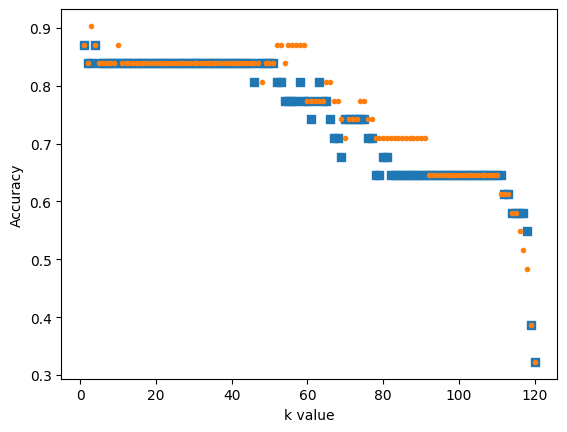

In [111]:
# Sandeep Durga
# We will test all possible K values for our euclidean and manhattan experimentation.
maxK = len(train_features_scaled)

def plotAccuracy(distanceType, markerType):
    accuracies = []
    
    for k in range(1,maxK):
        acc = knn_accuracy(train_features_scaled, train_labels, test_features_scaled, test_labels, k, distanceType)
        accuracies.append(acc)

    plt.scatter(x=list(range(1, maxK)), y=accuracies, marker=markerType)
    
    plt.xlabel('k value')
    plt.ylabel('Accuracy')

plotAccuracy('euclidean', 's')
plotAccuracy('manhattan', '.')

# Analysis of Euclidean and Manhattan graph:
# As we can see, as K increases the accuracy decreases. This is most like due to outliers skewing the predictions.
# KNN has no defense against outliers.
# Alot of accuracies seem to roughly match in k ranges of 1 to 50
# and 90 to 110. Around 110 k there is a very steep decline in accuracy.

best score is 0.9144086021505377, best k is 2


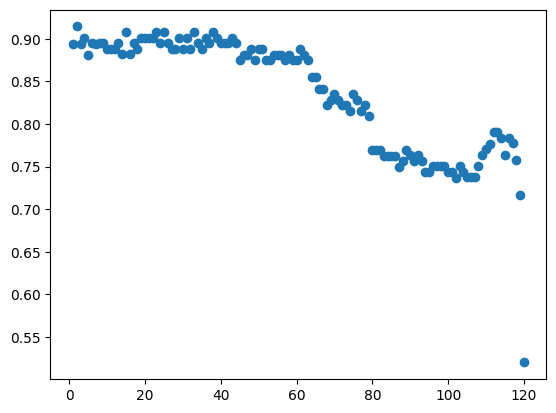

In [112]:
# Sandeep Durga
# Use KNN to predict species based of petal,sepal -> width and height
# NOTE: please wait several seconds for loop to finish, it is a bit slow
avg_accuracies = []

# K cannot be the entire dataframe since 1/5th of the rows
# will be used for testing.
best_k = 1
best_score = 0

for k in range(1, maxK):
    # Pipeline is essentially a list of operations applied to data given
    # to it in sequential order.
    estimator_pipeline = Pipeline([
        ('scaler',  StandardScaler()),
        ('knn_model', KNeighborsClassifier(n_neighbors=k, metric='euclidean'))
    ])
    
    score = cross_val_score(estimator_pipeline, shuffled_features, shuffled_labels).mean()
    avg_accuracies.append(score)

    # update score
    if score > best_score:
        best_score = score 
        best_k = k
    
print(f"best score is {best_score}, best k is {best_k}")
plt.scatter(x=list(range(1, maxK)), y=avg_accuracies)

# Analysis of cross_val_score:
# Again we see how accuracies are degrading as k increases.
# K shows significant drops in value around K = 60, 80, and 115.
# It does take some seconds(usually 6 to 10) to do all this cross validation
# since its using each 1/5th of the training data as a validation set.

In [113]:
# Sandeep Durga
# KNN using best k found

# bets distance method was euclidean
print(f'Best accuracy is: {knn_accuracy(train_features_scaled, train_labels, test_features_scaled, test_labels, best_k, 'euclidean')}')

predicted_labels = knn_helper(train_features_scaled, train_labels, test_features_scaled, best_k, 'euclidean')

# graph predicted and test labels
data = {
    'Predictions' : predicted_labels,
    'Correct Species' : test_labels,
}

prediction_table = pd.concat([pd.DataFrame(data), pd.DataFrame(test_features)], axis=1)
wrong_predictions = prediction_table[prediction_table['Predictions'] != prediction_table['Correct Species']]

display(wrong_predictions)
wrong_predictions.describe()

Best accuracy is: 0.8387096774193549


,Predictions,Correct Species,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
80,versicolor,virginica,6.386602,2.647653,4.687089,1.599591
95,versicolor,virginica,6.296112,2.613482,4.841012,1.478976
143,versicolor,virginica,5.768455,3.050530,5.306520,1.537974
130,versicolor,virginica,6.182383,2.873320,5.814199,1.683440
33,virginica,versicolor,6.774866,2.702907,4.811899,1.816408


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,5.000000,5.000000,5.000000,5.000000
mean,6.281684,2.777578,5.092144,1.623278
std,0.363218,0.182382,0.467171,0.131890
min,5.768455,2.613482,4.687089,1.478976
25%,6.182383,2.647653,4.811899,1.537974
50%,6.296112,2.702907,4.841012,1.599591
75%,6.386602,2.873320,5.306520,1.683440
max,6.774866,3.050530,5.814199,1.816408


##### Analysis of best K:
##### Versicolor is the most misclassified. 2nd place goes to virginica with 1 misclassification.
##### It seems Versicolor is the most difficult to classify.
##### Setosa seems to be the easiest.
##### For the first two rows it seems sepal length, sepal width, and petal length
##### have similar values to the fourth row. While the third row usually differs
##### from fourth. So that might not be whats causing versicolor and virginica
##### to differ. But it might be why versicolor is misclassified the most.
##### But that pattern is broken in the fourth row where the versicolor's petal width
##### is consistently around 1.5 while virginica is noticably larger.
##### Basically the versicolor values of sepal length, sepal width, and petal length
##### seems to surround or encompass the values in virginica.
##### Hence why the table shows them being confused for each other.

In [114]:
# Sandeep Durga
# Naive bayes

from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(train_features, train_labels)

# Sanity check
print(f"Classes: {gnb.classes_}")
print(f"Sample per class: {gnb.class_count_}")
print(f"Feature means shape:", gnb.theta_.shape)
print(f"Feature variances shape:", gnb.var_.shape)

print('Average of each feature per class(rows are the categories, columns are the features):')
display(pd.DataFrame(gnb.theta_, index=gnb.classes_, columns=['sepal length (cm)',	'sepal width (cm)',	'petal length (cm)',	'petal width (cm)']))

gaussian_pred = gnb.predict(test_features)
checked_pred = gaussian_pred == test_labels
print(f'Number of predictions: {len(checked_pred)}')
print(f'Number of Correct predictions: {checked_pred.sum()}')
print(f'Percentage of predictions that are correct: {gnb.score(test_features,test_labels)}')
print(accuracy_score(test_labels, gaussian_pred))

misclassified = gaussian_pred != test_labels

# show features + predictions + true output
misclassified_df = pd.DataFrame(test_features[misclassified])
misclassified_df['actual'] = test_labels[misclassified]
misclassified_df['prediction'] = gaussian_pred[misclassified]
misclassified_df

Classes: ['setosa' 'versicolor' 'virginica']
Sample per class: [41. 40. 40.]
Feature means shape: (3, 4)
Feature variances shape: (3, 4)
Average of each feature per class(rows are the categories, columns are the features):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,5.025835,3.390711,1.500420,0.322266
versicolor,5.947590,2.816011,4.269541,1.349666
virginica,6.758261,3.016289,5.674952,2.034637


Number of predictions: 31
Number of Correct predictions: 26
Percentage of predictions that are correct: 0.8387096774193549
0.8387096774193549


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual,prediction
80,6.386602,2.647653,4.687089,1.599591,virginica,versicolor
95,6.296112,2.613482,4.841012,1.478976,virginica,versicolor
143,5.768455,3.050530,5.306520,1.537974,virginica,versicolor
33,6.774866,2.702907,4.811899,1.816408,versicolor,virginica
77,6.605663,2.841501,5.008664,1.823922,versicolor,virginica


# Again virginica and versicolor are mistaken for each other.
# Petal width of versicolor and virginica are closer together than setosa and versicolor,
# so that may be another reason they get mixed up.